In [1]:
import pickle

exports_folder_path = "/private/schwartz-lab/yarin_shaked7/SkyRL/data/exports/"
sub_experiment_name = "Qwen3-4B_spartan_reward_coef_10.0_format_reward_coef_0.5_accuracy_reward_coef_1.0_context_4000_lr_1.0e-5/"
file_path = "eval_summary_table.pkl"
r_spartan_i_spartan_path = exports_folder_path + "L40_rewards_SPARTAN_instructions_SPARTAN_model_Qwen/" + sub_experiment_name + file_path
r_spartan_i_vanilla_path = exports_folder_path + "RTX6000_rewards_SPARTAN_instructions_VANILLA_model_Qwen/" + sub_experiment_name + file_path
r_vanilla_i_spartan_path = exports_folder_path + "RTX6000_rewards_VANILLA_instructions_SPARTAN_model_Qwen/" + sub_experiment_name + file_path
r_vanilla_i_vanilla_path = exports_folder_path + "RTX6000_rewards_VANILLA_instructions_VANILLA_model_Qwen/" + sub_experiment_name + file_path

with open(r_spartan_i_spartan_path, "rb") as f:
    r_spartan_i_spartan_data = pickle.load(f)
    r_spartan_i_spartan_data = r_spartan_i_spartan_data.get_dataframe()

with open(r_spartan_i_vanilla_path, "rb") as f:
    r_spartan_i_vanilla_data = pickle.load(f)
    r_spartan_i_vanilla_data = r_spartan_i_vanilla_data.get_dataframe()

with open(r_vanilla_i_spartan_path, "rb") as f:
    r_vanilla_i_spartan_data = pickle.load(f)
    r_vanilla_i_spartan_data = r_vanilla_i_spartan_data.get_dataframe()

with open(r_vanilla_i_vanilla_path, "rb") as f:
    r_vanilla_i_vanilla_data = pickle.load(f)
    r_vanilla_i_vanilla_data = r_vanilla_i_vanilla_data.get_dataframe()

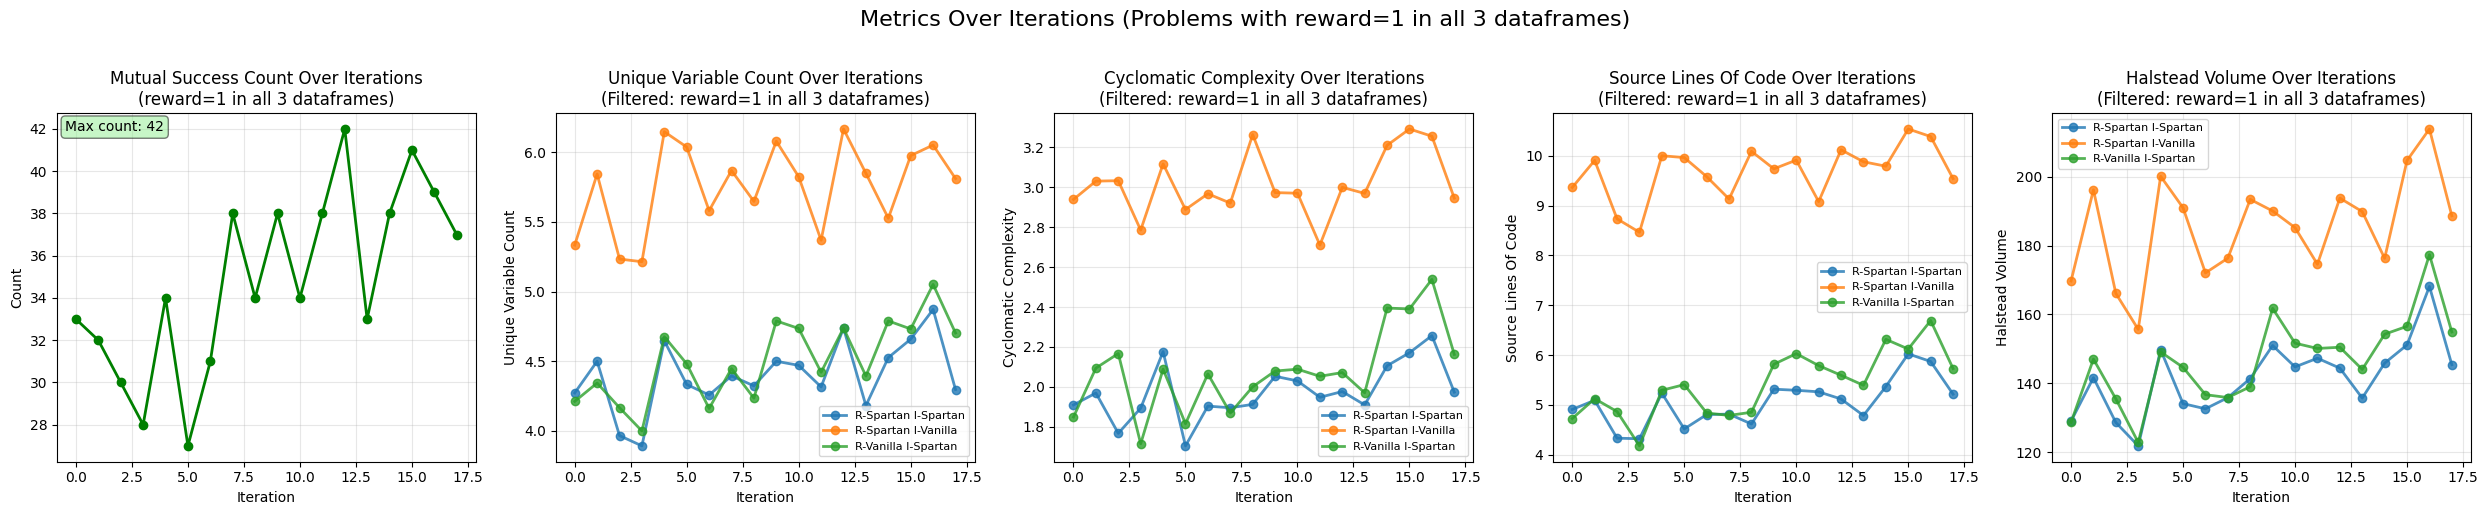


Summary:
Total iterations: 18
Dataset size per iteration: 279

Mutual Success Count (reward=1 in all 3 dataframes):
  Mean across iterations: 34.83
  Std across iterations: 4.18
  Min: 27, Max: 42

Unique Variable Count:
  R-Spartan I-Spartan:
    Mean: 4.3972, Std: 0.2430
    Min: 3.8929, Max: 4.8718
  R-Spartan I-Vanilla:
    Mean: 5.7531, Std: 0.3044
    Min: 5.2143, Max: 6.1667
  R-Vanilla I-Spartan:
    Mean: 4.5043, Std: 0.2772
    Min: 4.0000, Max: 5.0513

Cyclomatic Complexity:
  R-Spartan I-Spartan:
    Mean: 1.9749, Std: 0.1360
    Min: 1.7037, Max: 2.2564
  R-Spartan I-Vanilla:
    Mean: 3.0155, Std: 0.1556
    Min: 2.7105, Max: 3.2927
  R-Vanilla I-Spartan:
    Mean: 2.0781, Std: 0.2030
    Min: 1.7143, Max: 2.5385

Source Lines Of Code:
  R-Spartan I-Spartan:
    Mean: 5.0507, Std: 0.4526
    Min: 4.3214, Max: 6.0244
  R-Spartan I-Vanilla:
    Mean: 9.6782, Std: 0.5321
    Min: 8.4643, Max: 10.5366
  R-Vanilla I-Spartan:
    Mean: 5.4202, Std: 0.6321
    Min: 4.1786, Max:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dataset_size = 279

# Calculate number of iterations
num_iterations = len(r_spartan_i_spartan_data) // dataset_size

# Metrics to plot (excluding reward - we'll plot count instead)
metrics = [
    ("unique_variable_count", "Unique Variable Count"),
    ("cyclomatic_complexity", "Cyclomatic Complexity"),
    ("source_lines_of_code", "Source Lines Of Code"),
    ("halstead_volume", "Halstead Volume")
]

# Store results for each iteration - one list per dataframe per metric
# Excluding r_vanilla_i_vanilla_data
dataframes = {
    'r_spartan_i_spartan': r_spartan_i_spartan_data,
    'r_spartan_i_vanilla': r_spartan_i_vanilla_data,
    'r_vanilla_i_spartan': r_vanilla_i_spartan_data
}
dataframe_names = ['r_spartan_i_spartan', 'r_spartan_i_vanilla', 'r_vanilla_i_spartan']
dataframe_labels = ['R-Spartan I-Spartan', 'R-Spartan I-Vanilla', 'R-Vanilla I-Spartan']

# Store results for each dataframe and metric
iteration_results = {
    df_name: {metric[0]: [] for metric in metrics}
    for df_name in dataframe_names
}
mutual_success_count = []  # Store count of problems with reward=1 in all 3 dataframes

# Store percentage of reward=1 for all 4 dataframes (including r_vanilla_i_vanilla for this plot)
all_dataframes_for_percentage = {
    'r_spartan_i_spartan': r_spartan_i_spartan_data,
    'r_spartan_i_vanilla': r_spartan_i_vanilla_data,
    'r_vanilla_i_spartan': r_vanilla_i_spartan_data,
    'r_vanilla_i_vanilla': r_vanilla_i_vanilla_data
}
all_dataframe_names_for_percentage = ['r_spartan_i_spartan', 'r_spartan_i_vanilla', 'r_vanilla_i_spartan', 'r_vanilla_i_vanilla']
all_dataframe_labels_for_percentage = ['R-Spartan I-Spartan', 'R-Spartan I-Vanilla', 'R-Vanilla I-Spartan', 'R-Vanilla I-Vanilla']
reward_percentage = {df_name: [] for df_name in all_dataframe_names_for_percentage}  # Store percentage of reward=1 per iteration

# Process each iteration
for iteration in range(num_iterations):
    start_idx = iteration * dataset_size
    end_idx = (iteration + 1) * dataset_size
    
    # Extract data for this iteration from all 4 dataframes (for percentage calculation)
    iter_r_spartan_i_spartan = r_spartan_i_spartan_data.iloc[start_idx:end_idx].copy()
    iter_r_spartan_i_vanilla = r_spartan_i_vanilla_data.iloc[start_idx:end_idx].copy()
    iter_r_vanilla_i_spartan = r_vanilla_i_spartan_data.iloc[start_idx:end_idx].copy()
    iter_r_vanilla_i_vanilla = r_vanilla_i_vanilla_data.iloc[start_idx:end_idx].copy()
    
    # Calculate percentage of reward=1 for each dataframe
    iter_dataframes = {
        'r_spartan_i_spartan': iter_r_spartan_i_spartan,
        'r_spartan_i_vanilla': iter_r_spartan_i_vanilla,
        'r_vanilla_i_spartan': iter_r_vanilla_i_spartan,
        'r_vanilla_i_vanilla': iter_r_vanilla_i_vanilla
    }
    for df_name in all_dataframe_names_for_percentage:
        reward_1_count = (iter_dataframes[df_name]['reward'] == 1).sum()
        percentage = (reward_1_count / dataset_size) * 100
        reward_percentage[df_name].append(percentage)
    
    # Filter problems where reward=1 across all 3 dataframes
    # We need to align by index (assuming they're aligned by problem)
    mask = (
        (iter_r_spartan_i_spartan['reward'] == 1) &
        (iter_r_spartan_i_vanilla['reward'] == 1) &
        (iter_r_vanilla_i_spartan['reward'] == 1)
    )
    
    # Store count of mutual successes
    mutual_success_count.append(mask.sum())
    
    # Calculate metrics for filtered problems from each dataframe
    filtered_dataframes = {
        'r_spartan_i_spartan': iter_r_spartan_i_spartan[mask],
        'r_spartan_i_vanilla': iter_r_spartan_i_vanilla[mask],
        'r_vanilla_i_spartan': iter_r_vanilla_i_spartan[mask]
    }
    
    # Store mean values for each metric from each dataframe
    for df_name in dataframe_names:
        filtered_data = filtered_dataframes[df_name]
        for metric_name, _ in metrics:
            if len(filtered_data) > 0:
                metric_values = filtered_data[metric_name].dropna()
                if len(metric_values) > 0:
                    iteration_results[df_name][metric_name].append(metric_values.mean())
                else:
                    iteration_results[df_name][metric_name].append(np.nan)
            else:
                iteration_results[df_name][metric_name].append(np.nan)

# Create subplots (6 subplots: percentage + count + 4 metrics)
fig, axs = plt.subplots(1, 6, figsize=(30, 5))

# Plot percentage of reward=1 for each dataframe (first subplot)
percentage_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # 4 colors for 4 dataframes
for df_idx, df_name in enumerate(all_dataframe_names_for_percentage):
    axs[0].plot(range(num_iterations), reward_percentage[df_name], marker='o', linewidth=2,
                label=all_dataframe_labels_for_percentage[df_idx], color=percentage_colors[df_idx], alpha=0.8)
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Percentage (%)')
axs[0].set_title('Percentage of Samples with reward=1\nper Iteration (All Dataframes)')
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='best', fontsize=8)

# Plot count of mutual successes (second subplot)
axs[1].plot(range(num_iterations), mutual_success_count, marker='o', linewidth=2, color='green')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Count')
axs[1].set_title('Mutual Success Count Over Iterations\n(reward=1 in all 3 dataframes)')
axs[1].grid(True, alpha=0.3)
if len(mutual_success_count) > 0:
    axs[1].text(0.02, 0.98, f'Max count: {max(mutual_success_count)}', 
                transform=axs[1].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Plot each metric (remaining 4 subplots) - one line per dataframe
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Different colors for each dataframe (3 colors)
for idx, (metric_name, metric_label) in enumerate(metrics):
    ax_idx = idx + 2  # Start from index 2 (0 is percentage, 1 is count)
    
    # Plot a line for each dataframe
    for df_idx, df_name in enumerate(dataframe_names):
        values = iteration_results[df_name][metric_name]
        axs[ax_idx].plot(range(num_iterations), values, marker='o', linewidth=2, 
                        label=dataframe_labels[df_idx], color=colors[df_idx], alpha=0.8)
    
    axs[ax_idx].set_xlabel('Iteration')
    axs[ax_idx].set_ylabel(metric_label)
    axs[ax_idx].set_title(f'{metric_label} Over Iterations\n(Filtered: reward=1 in all 3 dataframes)')
    axs[ax_idx].grid(True, alpha=0.3)
    axs[ax_idx].legend(loc='best', fontsize=8)

plt.suptitle('Metrics Over Iterations (Problems with reward=1 in all 3 dataframes)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary:")
print(f"Total iterations: {num_iterations}")
print(f"Dataset size per iteration: {dataset_size}")
print(f"\nPercentage of Samples with reward=1 per Iteration:")
for df_idx, df_name in enumerate(all_dataframe_names_for_percentage):
    percentages = reward_percentage[df_name]
    print(f"  {all_dataframe_labels_for_percentage[df_idx]}:")
    print(f"    Mean: {np.mean(percentages):.2f}%, Std: {np.std(percentages):.2f}%")
    print(f"    Min: {np.min(percentages):.2f}%, Max: {np.max(percentages):.2f}%")
print(f"\nMutual Success Count (reward=1 in all 3 dataframes):")
print(f"  Mean across iterations: {np.mean(mutual_success_count):.2f}")
print(f"  Std across iterations: {np.std(mutual_success_count):.2f}")
print(f"  Min: {np.min(mutual_success_count)}, Max: {np.max(mutual_success_count)}")

for metric_name, metric_label in metrics:
    print(f"\n{metric_label}:")
    for df_idx, df_name in enumerate(dataframe_names):
        valid_values = [x for x in iteration_results[df_name][metric_name] if not np.isnan(x)]
        if valid_values:
            print(f"  {dataframe_labels[df_idx]}:")
            print(f"    Mean: {np.mean(valid_values):.4f}, Std: {np.std(valid_values):.4f}")
            print(f"    Min: {np.min(valid_values):.4f}, Max: {np.max(valid_values):.4f}")
